<a href="https://colab.research.google.com/github/muhammdumairnad/Price-Driven-Demand-Prediction-in-Retail-using-Machine-Learning/blob/main/Retail_Demand_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:


# Download the dataset
dataset_path = kagglehub.dataset_download("aswathrao/demand-forecasting")

# Construct the full path to the CSV filell
csv_file_path = os.path.join(dataset_path, 'train_0irEZ2H.csv')

# Read the CSV into a DataFrame
df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'demand-forecasting' dataset.


In [4]:
os.listdir(dataset_path) # chk files inside aswathrao/demand-forecasting

['test_nfaJ3J5.csv', 'train_0irEZ2H.csv', 'sample_submission_pzljTaX.csv']

In [5]:
#EDA
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [6]:
df.shape

(150150, 9)

In [7]:
(df==" ").sum()
#there is no null or emptu value in data set

,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,0
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [8]:
df.duplicated().sum()
# to check duplicated rows


np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [10]:
#df[['day','month','year']] = df['week'].str.split('/', expand=True).astype(int) # by spliting method
#also this way
df['week'] = pd.to_datetime(df['week'])
df['day'] = df['week'].dt.day
df['month'] = df['week'].dt.month
df['year'] = df['week'].dt.year
df['day'].head()

,day
0,17
1,17
2,17
3,17
4,17


In [11]:
df = df.drop('week', axis=1)

In [12]:
df.isnull().sum()

,0
record_ID,0
store_id,0
sku_id,0
total_price,1
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0
day,0
month,0


In [13]:
df['total_price'].fillna(df['base_price'], inplace=True)

In [14]:
df['store_id'].nunique()
#there are 76 stores data

76

In [15]:

df['discount'] = df['base_price'] - df['total_price']
# Fill any NaN values in discount that might arise from total_price still having NaNs before this fillna
df['discount'].fillna(0, inplace=True)

In [16]:
df['units_sold'].sort_values(ascending=False).head()

,units_sold
5607,2876
7917,1705
6762,1669
5559,1599
4917,1341


In [17]:
df.loc[[5607, 7917, 6762, 5559, 4917]]
# these are highly sold items. they are cheaper and discounted well. also ther are featured and displayed mostly

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
5607,7961,9845,219009,116.8500,227.2875,1,1,2876,14,2,2011,110.4375
7917,11210,9845,219009,116.8500,227.2875,1,1,1705,28,2,2011,110.4375
6762,9598,9845,219009,114.0000,227.2875,0,1,1669,21,2,2011,113.2875
5559,7894,9823,219009,118.9875,227.2875,1,0,1599,14,2,2011,108.3000
4917,6970,8869,219009,118.2750,225.8625,1,1,1341,14,2,2011,107.5875


In [18]:
df['sku_id'].nunique()


28

In [19]:
print(df['is_featured_sku'].value_counts())
print(df['is_display_sku'].value_counts())

is_featured_sku
0    135794
1     14356
Name: count, dtype: int64
is_display_sku
0    130150
1     20000
Name: count, dtype: int64


In [20]:
df.corr()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
record_ID,1.000000,7.464429e-03,-4.772670e-04,0.008497,0.018932,0.031358,0.020428,-0.010616,-6.319391e-02,9.035131e-02,9.296388e-01,0.038649
store_id,0.007464,1.000000e+00,-6.862856e-02,-0.038308,-0.038848,-0.008729,0.013440,-0.004372,1.407103e-15,-1.035187e-15,6.712204e-15,-0.011158
sku_id,-0.000477,-6.862856e-02,1.000000e+00,0.119327,0.119068,-0.022255,0.014911,-0.184380,-1.023893e-15,-1.057602e-15,7.678163e-15,0.027944
total_price,0.008497,-3.830780e-02,1.193275e-01,1.000000,0.958886,0.050348,-0.065935,-0.235634,-4.984163e-04,2.057189e-03,8.749467e-03,0.097633
base_price,0.018932,-3.884811e-02,1.190677e-01,0.958886,1.000000,0.214333,0.051909,-0.140032,-1.186965e-03,3.855568e-03,1.611673e-02,0.376055
is_featured_sku,0.031358,-8.729370e-03,-2.225491e-02,0.050348,0.214333,1.000000,0.426243,0.337751,-4.591098e-03,5.280908e-03,3.036698e-02,0.587249
is_display_sku,0.020428,1.343959e-02,1.491057e-02,-0.065935,0.051909,0.426243,1.000000,0.362662,-8.585295e-03,-3.103117e-02,3.670734e-02,0.397322
units_sold,-0.010616,-4.371507e-03,-1.843798e-01,-0.235634,-0.140032,0.337751,0.362662,1.000000,-8.090324e-03,2.993099e-03,-9.180354e-03,0.278283
day,-0.063194,1.407103e-15,-1.023893e-15,-0.000498,-0.001187,-0.004591,-0.008585,-0.008090,1.000000e+00,-9.577147e-02,-1.235546e-01,-0.002535
month,0.090351,-1.035187e-15,-1.057602e-15,0.002057,0.003856,0.005281,-0.031031,0.002993,-9.577147e-02,1.000000e+00,-1.542758e-01,0.006804


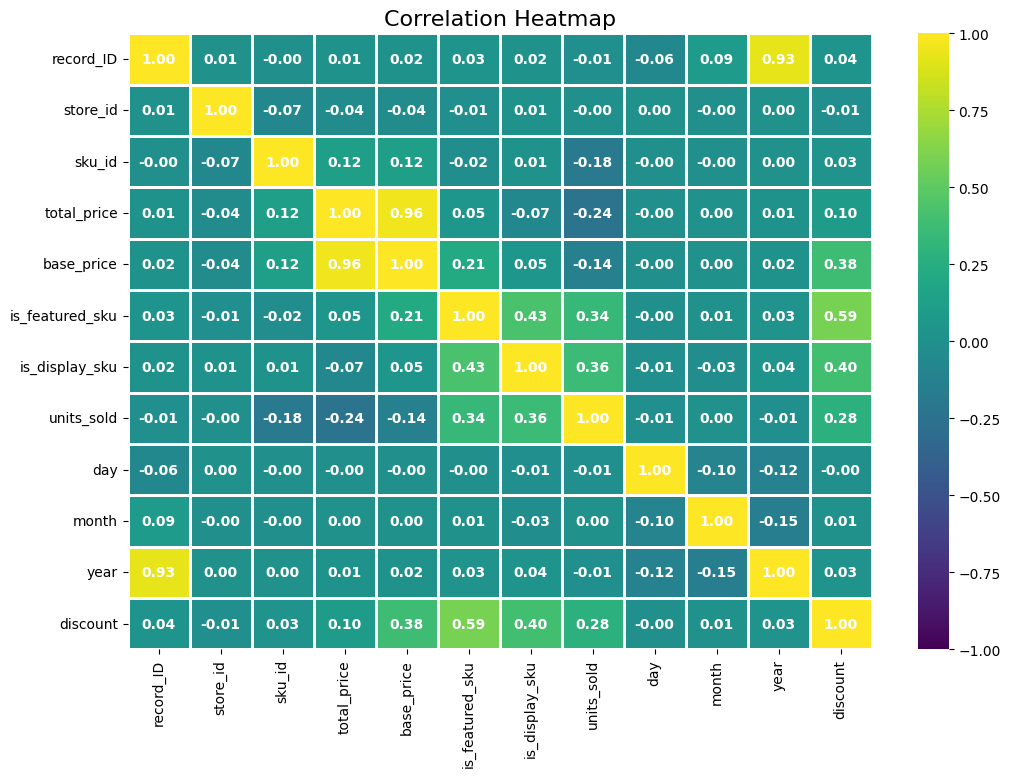

In [21]:
plt.figure(figsize=(12, 8))  # bigger heatmap

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          # 2 decimal places
    cmap='viridis',    # color style
    cbar=True,          # show color bar
    vmin=-1,
    vmax=1,
    center=0,           #correlation has both negative and positive values, centering at zero ensures a balanced color scale, making interpretation of relationships clearer.”
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 10, "color": "white", "weight": "bold"}  #Customize text inside boxes
)

plt.title('Correlation Heatmap', fontsize=16)

plt.show()

<Axes: xlabel='total_price', ylabel='units_sold'>

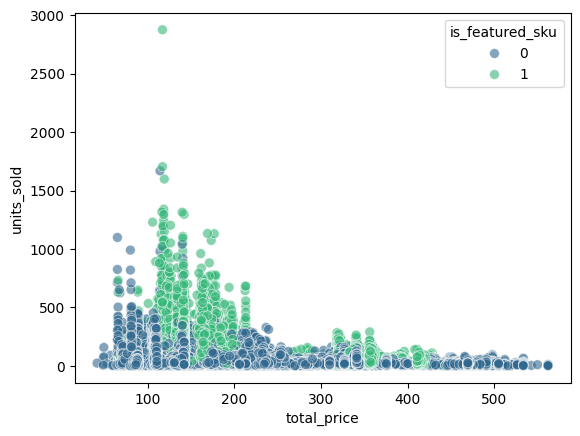

In [22]:
sns.scatterplot(
    x='total_price',
    y='units_sold',
    hue='is_featured_sku',  #Adds color based on category
    alpha=0.6,              #Helps when points overlap
    s=50,                   #control dot size
    palette='viridis',
    marker='o',             # change point shapes
    data=df
)

# Lower price → more sales

<Axes: xlabel='discount', ylabel='units_sold'>

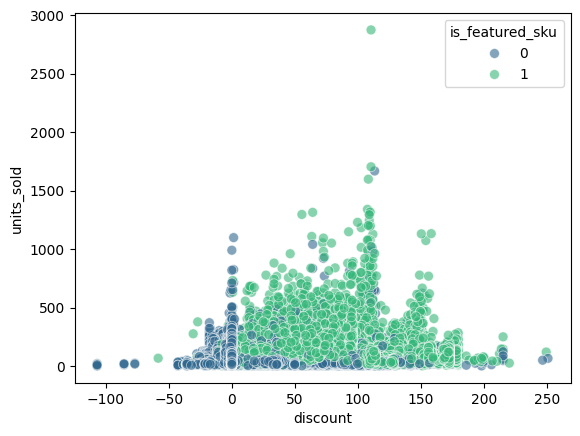

In [23]:
sns.scatterplot(
    x='discount',
    y='units_sold',
    hue='is_featured_sku',  #Adds color based on category

    alpha=0.6,              #Helps when points overlap
    s=50,                   #control dot size
    palette='viridis',
    marker='o',             # change point shapes
    data=df
)
#more sales when discount is given

In [24]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
count,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.628502,219.425927,0.095611,0.133200,51.674206,15.700000,6.130769,2011.830769,12.797425
std,61386.037861,615.591445,85547.306447,103.310400,110.961712,0.294058,0.339792,60.207904,8.944861,3.438232,0.755887,31.641226
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000,1.000000,1.000000,2011.000000,-106.875000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000,7.000000,3.000000,2011.000000,0.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000,16.000000,6.000000,2012.000000,0.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000,24.000000,9.000000,2012.000000,0.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000,31.000000,12.000000,2013.000000,250.800000


In [25]:
(df['discount'] < 0).sum()
df.loc[df['discount'] < 0, ['base_price', 'total_price', 'discount','units_sold']]

,base_price,total_price,discount,units_sold
70,88.3500,98.3250,-9.9750,233
71,88.3500,98.3250,-9.9750,256
95,116.1375,139.6500,-23.5125,82
142,82.6500,83.3625,-0.7125,49
143,71.2500,82.6500,-11.4000,46
...,...,...,...,...
149823,86.9250,87.6375,-0.7125,31
149824,87.6375,89.0625,-1.4250,20
150056,109.0125,110.4375,-1.4250,162
150061,174.5625,175.9875,-1.4250,107


In [26]:
df.loc[[70, 71, 95, 142, 143]]

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
70,93,8023,216418,98.3250,88.3500,0,1,233,17,1,2011,-9.9750
71,94,8023,216419,98.3250,88.3500,0,1,256,17,1,2011,-9.9750
95,125,8058,217390,139.6500,116.1375,0,1,82,17,1,2011,-23.5125
142,190,8218,216418,83.3625,82.6500,0,1,49,17,1,2011,-0.7125
143,191,8218,216419,82.6500,71.2500,0,1,46,17,1,2011,-11.4000


In [27]:
(df['total_price'] > df['base_price']).sum()

np.int64(3399)

In [28]:
df[df['total_price'] > df['base_price']]['units_sold'].describe()
# These represent price increases (negative discount) and may provide useful insights for model learning

,units_sold
count,3399.000000
mean,89.878788
std,66.179710
min,1.000000
25%,39.000000
50%,74.000000
75%,126.000000
max,651.000000


<Axes: title={'center': 'Impact of Display on Sales'}, xlabel='Display SKU', ylabel='Average Units Sold'>

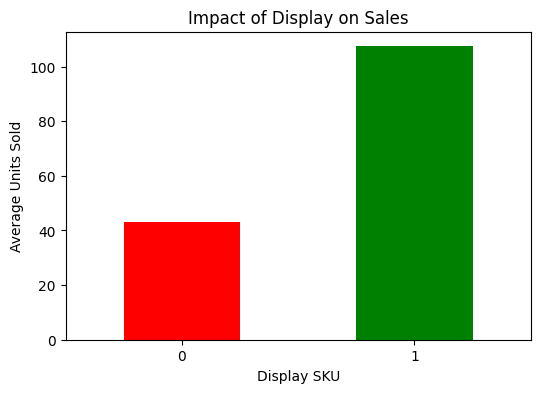

In [29]:
df.groupby('is_display_sku')['units_sold'].mean().plot(
    kind='bar',
    color=['red','green'],
    figsize=(6,4),
    title='Impact of Display on Sales',
    ylabel='Average Units Sold',
    xlabel='Display SKU',
    rot=0,
    )
# more sales for displayed items

<Axes: title={'center': 'Impact of Featured on Sales'}, xlabel='Featured SKU', ylabel='Average Units Sold'>

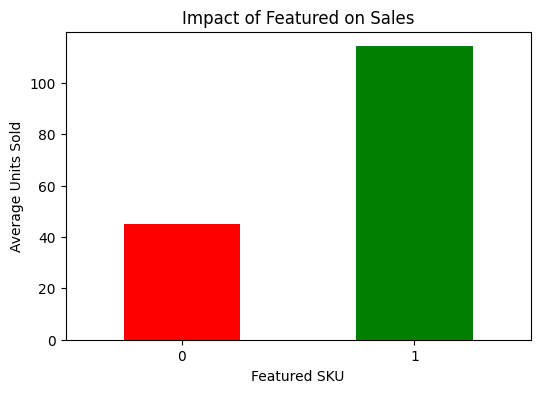

In [30]:
df.groupby('is_featured_sku')['units_sold'].mean().plot(kind='bar')
df.groupby('is_featured_sku')['units_sold'].mean().plot(
    kind='bar',
    color=['red','green'],
    figsize=(6,4),
    title='Impact of Featured on Sales',
    ylabel='Average Units Sold',
    xlabel='Featured SKU',
    rot= 0,  #angles (in degrees like 0,45,90) to rotate labels
    )

# more sales for featured items

In [31]:
# record_ID → useless
# base_price → redundant (highly correlated with total_price)
df.drop(['record_ID', 'base_price'], axis=1, inplace=True)


In [32]:
df.head()

,store_id,sku_id,total_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
0,8091,216418,99.0375,0,0,20,17,1,2011,12.825
1,8091,216419,99.0375,0,0,28,17,1,2011,0.000
2,8091,216425,133.9500,0,0,19,17,1,2011,0.000
3,8091,216233,133.9500,0,0,44,17,1,2011,0.000
4,8091,217390,141.0750,0,0,52,17,1,2011,0.000


In [33]:
df['sku_id'] = df['sku_id'].astype('category').cat.codes
# “First it converts text values into categorical labels, then assigns each category a numeric code so models can process it.”

In [34]:
df['sku_id'].unique()

array([ 1,  2,  3,  0,  5,  7,  8, 13, 12, 16,  9, 10, 18, 20, 11, 15, 14,
       24, 17,  4,  6, 21, 27, 23, 25, 22, 26, 19], dtype=int8)

In [35]:
df.drop('year', axis=1, inplace=True)

In [36]:
# Cyclic (or Circular) Feature Encoding
# Convert time features into circular form so model understands cycles

# Month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [37]:
df.drop(['month', 'day'], axis=1, inplace=True)

In [38]:
from sklearn.model_selection import train_test_split

# Drop rows with any remaining NaN values from the DataFrame
df.dropna(inplace=True)

X = df.drop('units_sold', axis=1)
y = df['units_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [39]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [40]:
#linear regression model
from sklearn.linear_model import LinearRegression
lg_model = model = LinearRegression(
    fit_intercept=True,             #Whether to calculate intercept (b₀)
    n_jobs=-1                       #Number of CPU cores to use
)
lg_model.fit(X_train,y_train)
y_pred = lg_model.predict(X_test)

mean_squared_error_lg = mean_squared_error(y_test,y_pred)
r2_score_lg = r2_score(y_test,y_pred)
mean_absolute_error_lg = mean_absolute_error(y_test,y_pred)


revenue_lg = (y_pred * X_test['total_price']).sum()  #Multiply predictions by price → then add everything
print("Total Revenue (Predicted):", revenue_lg)

print(f"Mean Squared Error: {mean_squared_error_lg}")
print(f"R2 Score: {r2_score_lg}")
print(f"Mean Absolute Error: {mean_absolute_error_lg}")




Total Revenue (Predicted): 278275314.47793233
Mean Squared Error: 2738.7623882237112
R2 Score: 0.250908759411003
Mean Absolute Error: 30.362311749907114


In [41]:
#XGB Regressor Model
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
#"RandomizedSearchCV is used to tune hyperparameters by randomly sampling combinations, training models using cross-validation, and selecting the best-performing model."
xgb = XGBRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}
xgb_model = RandomizedSearchCV(
    estimator=xgb,              # model
    param_distributions=param_grid,   # parameters to try
    n_iter=10,                  # number of trials
    scoring='r2',               # evaluation metric to chk which model is good
    cv=3,                       # cross-validation
    verbose=1,                  # show progress
    n_jobs=-1                   # use all CPU
)
xgb_model.fit(X_train,y_train)
y_pred = xgb_model.predict(X_test)

mean_squared_error_xgb = mean_squared_error(y_test,y_pred)
r2_score_xgb = r2_score(y_test,y_pred)
mean_absolute_error_xgb = mean_absolute_error(y_test,y_pred)


revenue_xgb = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_xgb)

print(f"Mean Squared Error: {mean_squared_error_xgb}")
print(f"R2 Score: {r2_score_xgb}")
print(f"Mean Absolute Error: {mean_absolute_error_xgb}")



Fitting 3 folds for each of 10 candidates, totalling 30 fits
Total Revenue (Predicted): 277438770.2885418
Mean Squared Error: 589.3139038085938
R2 Score: 0.8388141393661499
Mean Absolute Error: 13.145956993103027


In [42]:
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 10, 20]
}

lgbm_model = RandomizedSearchCV(
    lgbm,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
lgbm_model.fit(X_train,y_train)

mean_squared_error_lgbm = mean_squared_error(y_test,lgbm_model.predict(X_test))
r2_score_lgbm = r2_score(y_test,lgbm_model.predict(X_test))
mean_absolute_error_lgbm = mean_absolute_error(y_test,lgbm_model.predict(X_test))

y_pred = lgbm_model.predict(X_test)
revenue_lgbm = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_lgbm)

print(f"Mean Squared Error: {mean_squared_error_lgbm}")
print(f"R2 Score: {r2_score_lgbm}")
print(f"Mean Absolute Error: {mean_absolute_error_lgbm}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 120120, number of used features: 10
[LightGBM] [Info] Start training from score 51.574059
Total Revenue (Predicted): 277513566.4761984
Mean Squared Error: 756.3232496253731
R2 Score: 0.7931346202999285
Mean Absolute Error: 15.746220865626672


In [43]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [44]:
# CatBoostRegressor Model
from catboost import CatBoostRegressor

cat = CatBoostRegressor(verbose=0)

param_grid = {
    'iterations': [500, 800, 1200],          # increase a bit
    'depth': [4, 6, 8],                      # avoid very deep (10 can overfit)
    'learning_rate': [0.01, 0.03, 0.05],     # smaller = better generalization
    'l2_leaf_reg': [3, 5, 7],        # regularization : Controls how large the values in each leaf can become.
    'bagging_temperature': [0, 0.5, 1],   # randomness   : Controls how randomly data is sampled when building trees.
    'border_count': [64, 128, 254]       # feature splits : Controls how many bins/splits are created for continuous features.
}                                       # l2_leaf_reg        | Controls overfitting        | Low: Flexible (overfit risk)        | High: Stable (underfit risk)
                                        # bagging_temperature | Controls randomness        | Low: Deterministic                  | High: More randomness
                                        # border_count       | Controls split detail       | Low: Coarse splits                  | High: Fine-grained splits

cat_model = RandomizedSearchCV(
    cat,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
cat_model.fit(X_train,y_train)

mean_squared_error_cat = mean_squared_error(y_test,cat_model.predict(X_test))
r2_score_cat = r2_score(y_test,cat_model.predict(X_test))
mean_absolute_error_cat = mean_absolute_error(y_test,cat_model.predict(X_test))

y_pred = cat_model.predict(X_test)
revenue_cat = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_cat)

print(f"Mean Squared Error: {mean_squared_error_cat}")
print(f"R2 Score: {r2_score_cat}")
print(f"Mean Absolute Error: {mean_absolute_error_cat}")


Total Revenue (Predicted): 277679826.4272457
Mean Squared Error: 675.0805309621542
R2 Score: 0.815355682329236
Mean Absolute Error: 14.932500334529482


In [45]:
results = pd.DataFrame({
    "Model": ["LR","XGB","LGBM","CAT"],
    "RMSE": [np.sqrt(mean_squared_error_lg), np.sqrt(mean_squared_error_xgb), np.sqrt(mean_squared_error_lgbm), np.sqrt(mean_squared_error_cat)],
    "R2": [r2_score_lg, r2_score_xgb, r2_score_lgbm, r2_score_cat],
    "MAE": [mean_absolute_error_lg, mean_absolute_error_xgb, mean_absolute_error_lgbm, mean_absolute_error_cat],
    "Revenue": [revenue_lg, revenue_xgb, revenue_lgbm, revenue_cat]
})


In [46]:
print(results)
# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”

  Model       RMSE        R2        MAE       Revenue
0    LR  52.333186  0.250909  30.362312  2.782753e+08
1   XGB  24.275788  0.838814  13.145957  2.774388e+08
2  LGBM  27.501332  0.793135  15.746221  2.775136e+08
3   CAT  25.982312  0.815356  14.932500  2.776798e+08


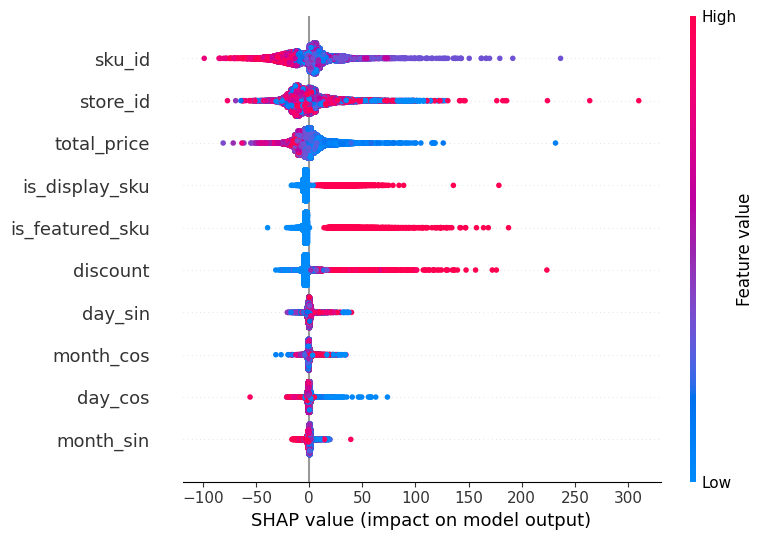

In [47]:
import shap


best_xgb = xgb_model.best_estimator_

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [48]:
# Model is over-relying on: sku_id AND store_id

#This means: Model is memorizing, Not generalizing,  predictions may fail SO WE DROP THESE 2 .WE DO IT ABOVE


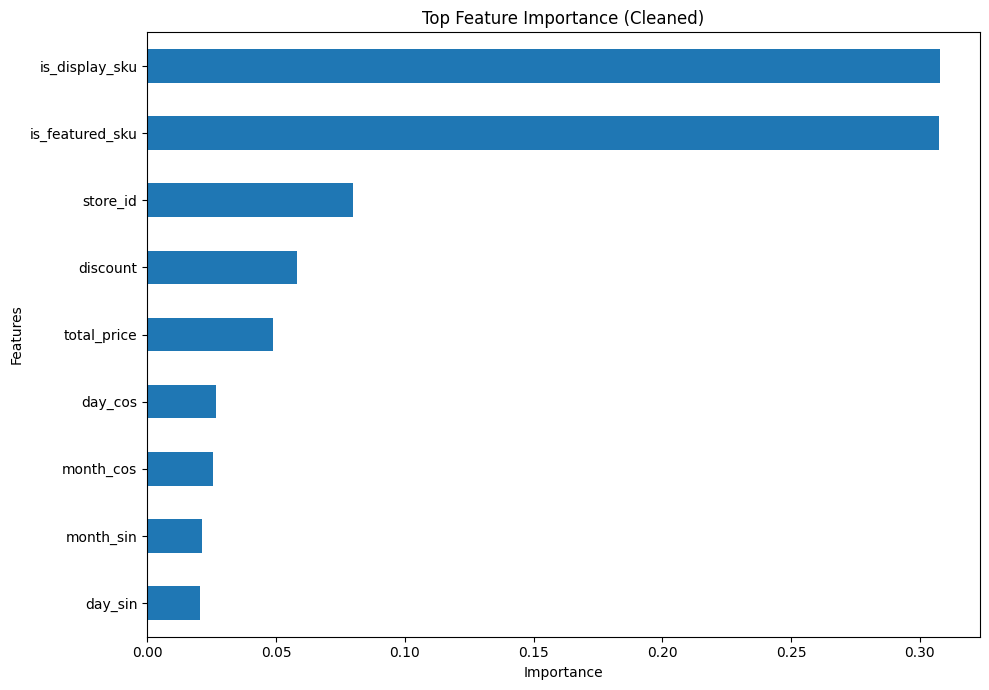

In [63]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
# Creates a table mapping each feature name to its importance score from the trained XGBoost model.

top_feat = feat_imp.sort_values(ascending=False).head(20)
# Sorts feature importance in descending order and selects the top 20 most important features.

# Remove sku , store columns
top_feat = top_feat[~top_feat.index.str.contains('sku_id')]

plt.figure(figsize=(10,7))
top_feat.sort_values().plot(kind='barh')

plt.title("Top Feature Importance (Cleaned)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()         # Automatically adjusts spacing in your plot so everything fits properly
plt.show()

# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”


In [50]:
# to chk which price product sold  to make maximum revenue
def optimize_price(sample_row, model):
    prices = np.linspace(
        X_test['total_price'].min(),
        X_test['total_price'].max(),
        50
    )

    best_price = None
    max_revenue = -np.inf

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        if revenue > max_revenue:
            max_revenue = revenue
            best_price = p

    return best_price, max_revenue


In [51]:

sample = X_test.iloc[20]

best_price, best_revenue = optimize_price(sample, best_xgb)

print("Optimal Price:", best_price)
print("Max Revenue:", best_revenue)

Optimal Price: 174.79515306122448
Max Revenue: 8768.08025026516


In [64]:
def plot_revenue_curve(sample_row, model):
    prices = np.linspace(
    X_test['total_price'].min(),
    X_test['total_price'].max(),
    50
)
    revenues = []
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        demands.append(pred_demand)
        revenues.append(revenue)

    # Plot
    plt.figure(figsize=(10,5))
    # Revenue curve
    plt.plot(prices, revenues)
    plt.xlabel("Price (scaled)")
    plt.ylabel("Revenue")
    plt.title("Revenue vs Price Curve")
    plt.show()



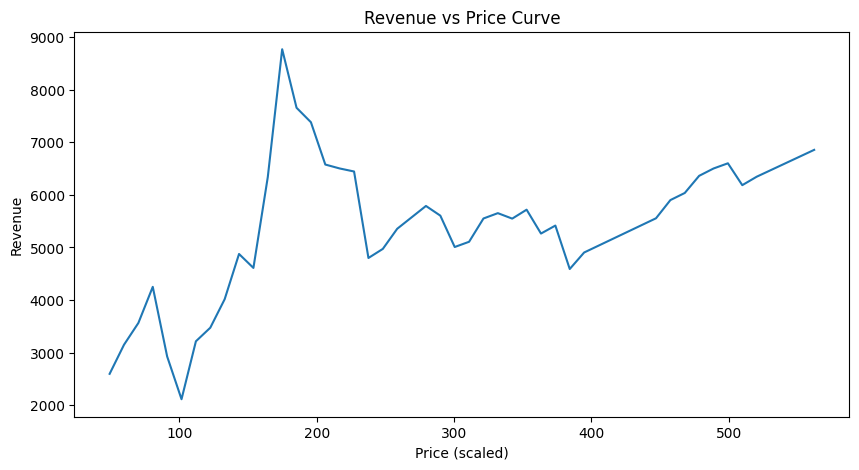

In [53]:
# Call the function to plot the revenue curve
plot_revenue_curve(sample, best_xgb)

In [54]:
# peaks shows optimal prices

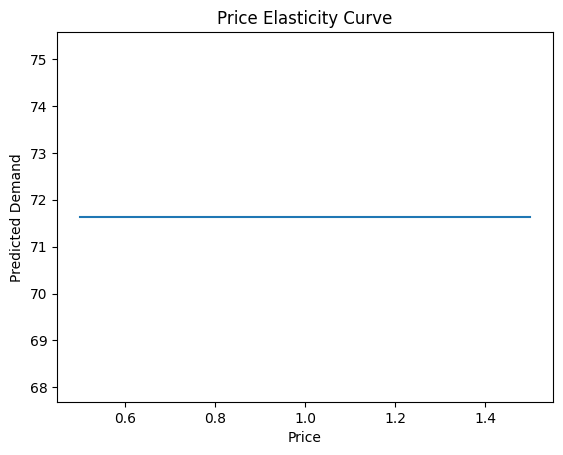

In [55]:
# Price Elasticity Graph

def plot_price_elasticity(sample_row, model):
    prices = np.linspace(0.5, 1.5, 50)
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p
        pred = model.predict(temp.values.reshape(1, -1))[0]
        demands.append(pred)

    plt.figure()
    plt.plot(prices, demands)
    plt.xlabel("Price")
    plt.ylabel("Predicted Demand")
    plt.title("Price Elasticity Curve")
    plt.show()

sample = X_test.iloc[0]
plot_price_elasticity(sample, best_xgb)

In [56]:
import joblib

# Save the best_xgb model first, as it was trained earlier in the notebook
joblib.dump(best_xgb, "model.pkl")

model = joblib.load("model.pkl")
# scaler = joblib.load("scaler.pkl") # No scaler was explicitly trained or saved, so this line is commented out

In [57]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.0 MB/s eta 0:00:00


In [58]:
pip install joblib

In [59]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>